# Time travel

## Review

We discussed motivations for human-in-the-loop:

- `Approval` - We can interrupt our agent, surface state to a user, and allow the user to accept an action
- `Debugging` - We can rewind the graph to reproduce or avoid issues
- `Editing` - You can modify the state

We showed how breakpoints can stop the graph at specific nodes or allow the graph to dynamically interrupt itself.

Then we showed how to proceed with human approval or directly edit the graph state with human feedback.

## Goals

Now, let's show how `LangGraph` [supports debugging](https://docs.langchain.com/oss/python/langgraph/use-time-travel) by **viewing, re-playing, and even forking** from past states.

We call this **time travel**.

In [1]:
import dotenv

dotenv.load_dotenv()

True

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
llm_with_tools = llm.bind_tools(tools)

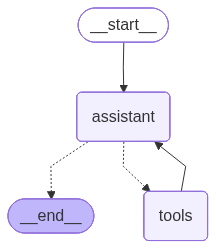

In [3]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(checkpointer=MemorySaver())

# Show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [4]:
# Input
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (5f4ecf85-a241-42fa-b616-6522b5a7b65d)
 Call ID: 5f4ecf85-a241-42fa-b616-6522b5a7b65d
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================


## Browsing History

We can use `get_state` to look at the current state of our graph, given the `thread_id`!

In [5]:
graph.get_state({'configurable': {'thread_id': '1'}})

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='77ffa339-d136-4582-898e-7e5a019de552'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dd032-c1b8-73c0-bec8-ff95ac846957-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '5f4ecf85-a241-42fa-b616-6522b5a7b65d', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 166, 'output_tokens': 18, 'total_tokens': 184, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='6', name='multiply', id='1b1ca6f4-d526-4e99-8e8c-2af0364bda30', tool_call_id='5f4ecf85-a241-42fa-b616-6522b5a7b65d'), AIMessage(content='', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-fl

We can also browse the state history of our agent.

`get_state_history` lets us get the state at all prior steps.

In [6]:
all_states = [s for s in graph.get_state_history(thread)]

In [7]:
len(all_states)

5

The first element is the current state, just as we got from `get_state`.

In [8]:
all_states[-2]

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='77ffa339-d136-4582-898e-7e5a019de552')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14266d-22f4-640c-8000-8503979d97c9'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-27T18:28:00.560623+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14266d-22ef-6b0b-bfff-ca2204903ada'}}, tasks=(PregelTask(id='4e07f547-1ced-bea6-3f8a-dcd6609d41c4', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dd032-c1b8-73

Everything above we can visualize here:

<img width="1024" src="https://camo.githubusercontent.com/8810b83a70e4ec769c29908448e7e6b4c423ab242c0f78397627a0913418eb16/68747470733a2f2f63646e2e70726f642e776562736974652d66696c65732e636f6d2f3635623863643732383335636565616364343434396135332f3636646262303338323131623534343839383537306265335f74696d652d74726176656c312e706e67" />

## Replaying

We can re-run our agent from any of the prior steps.

<img width="1024" src="https://camo.githubusercontent.com/b8eff99aee49b79f222c26969336a1dde1836e312eee32edf9f2191d7a64b1c2/68747470733a2f2f63646e2e70726f642e776562736974652d66696c65732e636f6d2f3635623863643732383335636565616364343434396135332f3636646262303338613062643334623534316337386662385f74696d652d74726176656c322e706e67" />

Let's look back at the step that recieved human input!

In [9]:
to_replay = all_states[-2]
to_replay

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='77ffa339-d136-4582-898e-7e5a019de552')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14266d-22f4-640c-8000-8503979d97c9'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-27T18:28:00.560623+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14266d-22ef-6b0b-bfff-ca2204903ada'}}, tasks=(PregelTask(id='4e07f547-1ced-bea6-3f8a-dcd6609d41c4', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dd032-c1b8-73

In [10]:
to_replay.values

{'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='77ffa339-d136-4582-898e-7e5a019de552')]}

In [11]:
to_replay.next

('assistant',)

In [12]:
to_replay.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f14266d-22f4-640c-8000-8503979d97c9'}}

To replay from here, we simply pass the config back to the agent!

The graph knows that this checkpoint has aleady been executed.

It just re-plays from this checkpoint!

In [13]:
for event in graph.stream(None, to_replay.config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (8a7c1b25-9388-41e1-bb83-5677ad7da996)
 Call ID: 8a7c1b25-9388-41e1-bb83-5677ad7da996
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================


Now, we can see our current state after the agent re-ran.

## Forking

What if we want to run from that same step, but with a different input.

This is forking.

<img width="1024" src="https://camo.githubusercontent.com/895407da2d6e43675701ecc25fc770b445bd8799a6573a6b3a92990758c0d2d6/68747470733a2f2f63646e2e70726f642e776562736974652d66696c65732e636f6d2f3635623863643732383335636565616364343434396135332f3636646262303338663839663264383437656535633333365f74696d652d74726176656c332e706e67" />

In [14]:
to_fork = all_states[-2]
to_fork.values["messages"]

[HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='77ffa339-d136-4582-898e-7e5a019de552')]

In [15]:
to_fork.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f14266d-22f4-640c-8000-8503979d97c9'}}

Let's modify the state at this checkpoint.

We can just run `update_state` with the `checkpoint_id` supplied.

Remember how our reducer on messages works:

- It will append, unless we supply a message ID.
- We supply the message ID to overwrite the message, rather than appending to state!

So, to overwrite the the message, we just supply the message ID, which we have `to_fork.values["messages"].id`.

In [16]:
fork_config = graph.update_state(
    to_fork.config,
    {"messages": [HumanMessage(content='Multiply 5 and 3', 
                               id=to_fork.values["messages"][0].id)]},
)

fork_config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f14266f-f489-6f48-8001-fcf12ff89a48'}}

This creates a new, forked checkpoint.

But, the metadata - e.g., where to go next - is perserved!

We can see the current state of our agent has been updated with our fork.

In [17]:
all_states = [state for state in graph.get_state_history(thread) ]
all_states[0].values["messages"]

[HumanMessage(content='Multiply 5 and 3', additional_kwargs={}, response_metadata={}, id='77ffa339-d136-4582-898e-7e5a019de552')]

In [18]:
len(all_states)

10

In [19]:
graph.get_state({'configurable': {'thread_id': '1'}})

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 5 and 3', additional_kwargs={}, response_metadata={}, id='77ffa339-d136-4582-898e-7e5a019de552')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14266f-f489-6f48-8001-fcf12ff89a48'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-04-27T18:29:16.224267+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14266d-22f4-640c-8000-8503979d97c9'}}, tasks=(PregelTask(id='efd2fdae-222b-c9ea-3283-0e8647591ca2', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [20]:
for event in graph.stream(None, fork_config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 5 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (4e4db0b8-2835-416f-ad83-0af6a66b36c1)
 Call ID: 4e4db0b8-2835-416f-ad83-0af6a66b36c1
  Args:
    a: 5
    b: 3
================================= Tool Message =================================
Name: multiply

15
================================== Ai Message ==================================

The answer is 15.


In [21]:
graph.get_state({'configurable': {'thread_id': '1'}})

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 5 and 3', additional_kwargs={}, response_metadata={}, id='77ffa339-d136-4582-898e-7e5a019de552'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 5, "b": 3}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dd034-1f2f-7dc0-a392-033b1f49598b-0', tool_calls=[{'name': 'multiply', 'args': {'a': 5, 'b': 3}, 'id': '4e4db0b8-2835-416f-ad83-0af6a66b36c1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 166, 'output_tokens': 18, 'total_tokens': 184, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='15', name='multiply', id='0cff532e-359a-42fb-8f28-15f6402e97de', tool_call_id='4e4db0b8-2835-416f-ad83-0af6a66b36c1'), AIMessage(content='The answer is 15.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_nam

## Time travel with LangGraph API

In [22]:
from langgraph_sdk import get_client
client = get_client(url="http://127.0.0.1:2024")

## Re-playing

Let's run our agent streaming updates to the state of the graph after each node is called.

In [23]:
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

thread = await client.threads.create()

async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id = "agent",
    input=initial_input,
    stream_mode="updates",
):
    if chunk.data:
        assisant_node = chunk.data.get('assistant', {}).get('messages', [])
        tool_node = chunk.data.get('tools', {}).get('messages', [])
        if assisant_node:
            print("-" * 20+"Assistant Node"+"-" * 20)
            print(assisant_node[-1])
        elif tool_node:
            print("-" * 20+"Tools Node"+"-" * 20)
            print(tool_node[-1])

--------------------Assistant Node--------------------
{'content': '', 'additional_kwargs': {'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}}, 'response_metadata': {'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, 'type': 'ai', 'name': None, 'id': 'lc_run--019dd035-76a3-77d1-a1ba-d9e2b77ab327-0', 'tool_calls': [{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'd3dc2718-0624-490b-97b4-3bbffb081bba', 'type': 'tool_call'}], 'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 169, 'output_tokens': 18, 'total_tokens': 187, 'input_token_details': {'cache_read': 0}}}
--------------------Tools Node--------------------
{'content': '6', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'tool', 'name': 'multiply', 'id': 'ccb5e052-73f3-4eab-a05a-ec8dc97b2adb', 'tool_call_id': 'd3dc2718-0624-490b-97b4-3bbffb081bba', 'artifact': None, 'status': 'success'}
--------------------Assistant 

Now, let's look at replaying from a specified checkpoint.

We simply need to pass the checkpoint_id.

In [24]:
states = await client.threads.get_history(thread['thread_id'])
to_replay = states[-2]
to_replay

{'values': {'messages': [{'content': 'Multiply 2 and 3',
    'additional_kwargs': {},
    'response_metadata': {},
    'type': 'human',
    'name': None,
    'id': 'e0c28bb5-2e7f-4aad-9644-39abe2554e7a'}]},
 'next': ['assistant'],
 'tasks': [{'id': '5f941430-05fc-ddc2-5f58-a5ddec47aaf1',
   'name': 'assistant',
   'path': ['__pregel_pull', 'assistant'],
   'error': None,
   'interrupts': [],
   'checkpoint': None,
   'state': None,
   'result': {'messages': [{'content': '',
      'additional_kwargs': {'function_call': {'name': 'multiply',
        'arguments': '{"a": 2, "b": 3}'}},
      'response_metadata': {'finish_reason': 'STOP',
       'model_name': 'gemini-2.5-flash-lite',
       'safety_ratings': [],
       'model_provider': 'google_genai'},
      'type': 'ai',
      'name': None,
      'id': 'lc_run--019dd035-76a3-77d1-a1ba-d9e2b77ab327-0',
      'tool_calls': [{'name': 'multiply',
        'args': {'a': 2, 'b': 3},
        'id': 'd3dc2718-0624-490b-97b4-3bbffb081bba',
        't

Let's stream with `stream_mode="values"` to see the full state at every node as we replay.

In [25]:
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input=None,
    stream_mode="values",
    checkpoint_id=to_replay['checkpoint_id']
):      
    print(f"Receiving new event of type: {chunk.event}...")
    print(chunk.data)
    print("\n\n")

Receiving new event of type: metadata...
{'run_id': '019dd037-532a-7792-b459-79b945406c6a', 'attempt': 1}



Receiving new event of type: values...
{'messages': [{'content': 'Multiply 2 and 3', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': 'e0c28bb5-2e7f-4aad-9644-39abe2554e7a'}]}



Receiving new event of type: values...
{'messages': [{'content': 'Multiply 2 and 3', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': 'e0c28bb5-2e7f-4aad-9644-39abe2554e7a'}, {'content': '', 'additional_kwargs': {'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}}, 'response_metadata': {'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, 'type': 'ai', 'name': None, 'id': 'lc_run--019dd037-5598-78f0-9972-183b01f9ebf1-0', 'tool_calls': [{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'a9aba8f0-1d5a-45b0-8132-1c807ef65ba7', 'type': 'tool_c

We can all view this as streaming only updates to state made by the nodes that we reply.

In [26]:
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input=None,
    stream_mode="updates",
    checkpoint_id=to_replay['checkpoint_id']
):
    if chunk.data:
        assisant_node = chunk.data.get('assistant', {}).get('messages', [])
        tool_node = chunk.data.get('tools', {}).get('messages', [])
        if assisant_node:
            print("-" * 20+"Assistant Node"+"-" * 20)
            print(assisant_node[-1])
        elif tool_node:
            print("-" * 20+"Tools Node"+"-" * 20)
            print(tool_node[-1])

--------------------Assistant Node--------------------
{'content': '', 'additional_kwargs': {'function_call': {'name': 'multiply', 'arguments': '{"b": 3, "a": 2}'}}, 'response_metadata': {'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, 'type': 'ai', 'name': None, 'id': 'lc_run--019dd038-75f9-7d60-8eb4-d31c7d6cd477-0', 'tool_calls': [{'name': 'multiply', 'args': {'b': 3, 'a': 2}, 'id': '1f575c87-1885-4505-9435-f7836058e14e', 'type': 'tool_call'}], 'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 169, 'output_tokens': 18, 'total_tokens': 187, 'input_token_details': {'cache_read': 0}}}
--------------------Tools Node--------------------
{'content': '6', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'tool', 'name': 'multiply', 'id': 'ed57c20d-9c21-4d7e-9476-e0adf40eb03b', 'tool_call_id': '1f575c87-1885-4505-9435-f7836058e14e', 'artifact': None, 'status': 'success'}
--------------------Assistant 

## Forking

Now, let's look at forking.

Let's get the same step as we worked with above, the human input.

Let's create a new thread with our agent.

In [27]:
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

thread = await client.threads.create()

async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input=initial_input,
    stream_mode="updates",
):
    if chunk.data:
        assisant_node = chunk.data.get('assistant', {}).get('messages', [])
        tool_node = chunk.data.get('tools', {}).get('messages', [])
        if assisant_node:
            print("-" * 20+"Assistant Node"+"-" * 20)
            print(assisant_node[-1])
        elif tool_node:
            print("-" * 20+"Tools Node"+"-" * 20)
            print(tool_node[-1])

--------------------Assistant Node--------------------
{'content': '', 'additional_kwargs': {'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}}, 'response_metadata': {'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, 'type': 'ai', 'name': None, 'id': 'lc_run--019dd039-5d61-70a3-b126-5abd69513f16-0', 'tool_calls': [{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '4191f3cb-1703-46a0-b57a-fa0afe9939d0', 'type': 'tool_call'}], 'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 169, 'output_tokens': 18, 'total_tokens': 187, 'input_token_details': {'cache_read': 0}}}
--------------------Tools Node--------------------
{'content': '6', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'tool', 'name': 'multiply', 'id': '258c9719-e307-461d-91da-42eba0bd2323', 'tool_call_id': '4191f3cb-1703-46a0-b57a-fa0afe9939d0', 'artifact': None, 'status': 'success'}
--------------------Assistant 

In [28]:
states = await client.threads.get_history(thread['thread_id'])
to_fork = states[-2]
to_fork['values']

{'messages': [{'content': 'Multiply 2 and 3',
   'additional_kwargs': {},
   'response_metadata': {},
   'type': 'human',
   'name': None,
   'id': 'bd3001d0-62b8-4511-a81d-3cee377f229e'}]}

In [29]:
to_fork['values']['messages'][0]['id']

'bd3001d0-62b8-4511-a81d-3cee377f229e'

In [30]:
to_fork['next']

['assistant']

In [31]:
to_fork['checkpoint_id']

'1f14267d-4508-6a95-8000-28af21154966'

Let's edit the state.

Remember how our reducer on messages works:

- It will append, unless we supply a message ID.
- We supply the message ID to overwrite the message, rather than appending to state!

In [32]:
forked_input = {"messages": HumanMessage(content="Multiply 3 and 3",
                                         id=to_fork['values']['messages'][0]['id'])}

forked_config = await client.threads.update_state(
    thread["thread_id"],
    forked_input,
    checkpoint_id=to_fork['checkpoint_id']
)

In [33]:
forked_config

{'checkpoint': {'thread_id': '2f8aedec-5110-4568-8733-84c59c1aa1c1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f142680-82ee-6728-8001-07c63001ce5d'},
 'configurable': {'thread_id': '2f8aedec-5110-4568-8733-84c59c1aa1c1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f142680-82ee-6728-8001-07c63001ce5d'},
 'checkpoint_id': '1f142680-82ee-6728-8001-07c63001ce5d'}

In [34]:
states = await client.threads.get_history(thread['thread_id'])
states[0]

{'values': {'messages': [{'content': 'Multiply 3 and 3',
    'additional_kwargs': {},
    'response_metadata': {},
    'type': 'human',
    'name': None,
    'id': 'bd3001d0-62b8-4511-a81d-3cee377f229e'}]},
 'next': ['assistant'],
 'tasks': [{'id': '7700c0a7-378b-344c-d1bb-9321edfee063',
   'name': 'assistant',
   'path': ['__pregel_pull', 'assistant'],
   'error': None,
   'interrupts': [],
   'checkpoint': None,
   'state': None,
   'result': None}],
 'metadata': {'graph_id': 'agent',
  'thread_id': '2f8aedec-5110-4568-8733-84c59c1aa1c1',
  'checkpoint_id': '1f14267d-4508-6a95-8000-28af21154966',
  'source': 'update',
  'step': 1,
  'parents': {}},
 'created_at': '2026-04-27T18:36:40.651930+00:00',
 'checkpoint': {'checkpoint_id': '1f142680-82ee-6728-8001-07c63001ce5d',
  'thread_id': '2f8aedec-5110-4568-8733-84c59c1aa1c1',
  'checkpoint_ns': ''},
 'parent_checkpoint': {'checkpoint_id': '1f14267d-4508-6a95-8000-28af21154966',
  'thread_id': '2f8aedec-5110-4568-8733-84c59c1aa1c1',
  '

To rerun, we pass in the `checkpoint_id`.

In [35]:
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input=None,
    stream_mode="updates",
    checkpoint_id=forked_config['checkpoint_id']
):
    if chunk.data:
        assisant_node = chunk.data.get('assistant', {}).get('messages', [])
        tool_node = chunk.data.get('tools', {}).get('messages', [])
        if assisant_node:
            print("-" * 20+"Assistant Node"+"-" * 20)
            print(assisant_node[-1])
        elif tool_node:
            print("-" * 20+"Tools Node"+"-" * 20)
            print(tool_node[-1])

--------------------Assistant Node--------------------
{'content': '', 'additional_kwargs': {'function_call': {'name': 'multiply', 'arguments': '{"a": 3, "b": 3}'}}, 'response_metadata': {'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, 'type': 'ai', 'name': None, 'id': 'lc_run--019dd03b-50dd-7fe0-9e98-da11e65a79ee-0', 'tool_calls': [{'name': 'multiply', 'args': {'a': 3, 'b': 3}, 'id': 'd17d8ccd-f20c-4127-b88d-a760aaab7d27', 'type': 'tool_call'}], 'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 169, 'output_tokens': 18, 'total_tokens': 187, 'input_token_details': {'cache_read': 0}}}
--------------------Tools Node--------------------
{'content': '9', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'tool', 'name': 'multiply', 'id': '0c4f7733-1aa6-4994-b2ce-4f8d61ee4f0d', 'tool_call_id': 'd17d8ccd-f20c-4127-b88d-a760aaab7d27', 'artifact': None, 'status': 'success'}
--------------------Assistant 